# Scam Website Detection Model Training

This notebook mirrors `train_model.py`. It trains from `dataset/reference_training_dataset_5000.csv`, writes a cleaned numeric dataset to `dataset/reference_training_dataset_5000_clean.csv`, compares candidate models with stratified cross-validation, calibrates the selected model by default, and saves the final artifacts under `pkl_models/`.


In [1]:
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from train_model import (
    DEFAULT_CLEAN_DATASET,
    DEFAULT_DATASET,
    MODEL_DIR,
    RANDOM_STATE,
    candidate_models,
    evaluate_candidates,
    holdout_metrics,
    load_clean_dataset,
)

warnings.filterwarnings('ignore')

DATA_PATH = DEFAULT_DATASET
CLEAN_DATA_PATH = DEFAULT_CLEAN_DATASET
MODEL_DIR.mkdir(parents=True, exist_ok=True)
CALIBRATE = True
TEST_SIZE = 0.20


## Load And Clean Dataset


In [2]:
clean, feature_columns = load_clean_dataset(DATA_PATH, CLEAN_DATA_PATH)
X = clean[feature_columns]
y = clean['label']

print('Raw dataset:', DATA_PATH)
print('Clean dataset:', CLEAN_DATA_PATH)
print('Rows:', len(clean))
print('Features:', len(feature_columns))
display(clean.head())
display(y.value_counts().rename({0: 'legit', 1: 'scam'}))


Raw dataset: dataset\reference_training_dataset_5000.csv
Clean dataset: dataset\reference_training_dataset_5000_clean.csv
Rows: 5000
Features: 35


,label,url_length,num_dots,num_hyphen,num_slashes,https,subdomains,has_at_symbol,has_double_slash,has_ip,...,uses_free_hosting,brand_on_free_hosting,brand_domain_mismatch,text_length,token_count,scam_keyword_count,scam_keyword_density,exclamation_count,caps_ratio,avg_word_length
0,0,41,4,0,4,0,1,0,0,0,...,0,0,0,0,0,0,0.00,0,0.0000,0.0
1,1,42,1,3,3,0,0,0,0,0,...,0,0,0,249,25,1,0.04,0,0.1641,6.6
2,1,19,1,0,3,0,0,0,0,0,...,0,0,0,238,25,2,0.08,1,0.0561,6.4
3,0,108,3,6,6,0,2,0,0,0,...,0,0,0,0,0,0,0.00,0,0.0000,0.0
4,0,26,2,1,4,0,1,0,0,0,...,0,0,0,0,0,0,0.00,0,0.0000,0.0


label
legit    2500
scam     2500
Name: count, dtype: int64

## Basic Dataset Checks


In [3]:
print('Missing values by column:')
display(clean.isna().sum().sort_values(ascending=False).head(20))

constant_cols = [col for col in feature_columns if clean[col].nunique(dropna=False) <= 1]
print('Constant numeric feature columns:', constant_cols)

display(clean[feature_columns].describe().T[['mean', 'std', 'min', 'max']].head(20))


Missing values by column:


label                    0
url_length               0
url_entropy              0
hostname_length          0
digit_letter_ratio       0
num_special_chars        0
tld_in_path              0
longest_digit_run        0
uses_free_hosting        0
brand_on_free_hosting    0
brand_domain_mismatch    0
text_length              0
token_count              0
scam_keyword_count       0
scam_keyword_density     0
exclamation_count        0
caps_ratio               0
suspicious_word_count    0
is_shortened             0
brand_in_url             0
dtype: int64

Constant numeric feature columns: []


,mean,std,min,max
url_length,42.666200,47.731323,14.0000,1201.0000
num_dots,1.881600,0.823479,1.0000,9.0000
num_hyphen,0.704600,1.290609,0.0000,19.0000
num_slashes,3.341000,1.079885,2.0000,13.0000
https,0.663200,0.472663,0.0000,1.0000
subdomains,0.665400,0.598594,0.0000,5.0000
has_at_symbol,0.004000,0.063125,0.0000,1.0000
has_double_slash,0.001400,0.037394,0.0000,1.0000
has_ip,0.012200,0.109789,0.0000,1.0000
num_underscores,0.099600,0.673328,0.0000,20.0000


## Train/Test Split


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Train labels:')
print(y_train.value_counts(normalize=True).sort_index())
print('Test labels:')
print(y_test.value_counts(normalize=True).sort_index())


Train shape: (4000, 35)
Test shape: (1000, 35)
Train labels:
label
0    0.5
1    0.5
Name: proportion, dtype: float64
Test labels:
label
0    0.5
1    0.5
Name: proportion, dtype: float64


## Candidate Models


In [5]:
models = candidate_models()
list(models)


['extra_trees',
 'random_forest',
 'gradient_boosting',
 'logistic_regression',
 'svc_rbf']

## Cross-Validate Candidates


In [6]:
cv_results = evaluate_candidates(X_train, y_train)
cv_results_df = pd.DataFrame(cv_results)
display(cv_results_df.round(4))


[CV] extra_trees: f1=0.9546, auc=0.9909, acc=0.9550


[CV] random_forest: f1=0.9538, auc=0.9902, acc=0.9540


[CV] gradient_boosting: f1=0.9528, auc=0.9898, acc=0.9533


[CV] logistic_regression: f1=0.9336, auc=0.9842, acc=0.9343


[CV] svc_rbf: f1=0.9452, auc=0.9872, acc=0.9460


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,extra_trees,0.9550,0.0106,0.9610,0.0067,0.9485,0.0173,0.9546,0.0110,0.9909,0.0025
1,random_forest,0.9540,0.0069,0.9577,0.0081,0.9500,0.0119,0.9538,0.0070,0.9902,0.0026
2,gradient_boosting,0.9532,0.0078,0.9605,0.0086,0.9455,0.0160,0.9528,0.0082,0.9898,0.0031
3,svc_rbf,0.9460,0.0088,0.9589,0.0097,0.9320,0.0109,0.9452,0.0090,0.9872,0.0041
4,logistic_regression,0.9343,0.0106,0.9433,0.0099,0.9240,0.0127,0.9336,0.0108,0.9842,0.0048


## Train Best Model


In [7]:
best_model_name = cv_results[0]['model']
best_model = candidate_models()[best_model_name]
best_model.fit(X_train, y_train)

final_model = best_model
if CALIBRATE:
    final_model = CalibratedClassifierCV(best_model, method='isotonic', cv=3)
    final_model.fit(X_train, y_train)

print('Best model:', best_model_name)
print('Calibrated:', CALIBRATE)


Best model: extra_trees
Calibrated: True


## Holdout Evaluation


In [8]:
y_pred = final_model.predict(X_test)
y_score = final_model.predict_proba(X_test)[:, 1] if hasattr(final_model, 'predict_proba') else y_pred
metrics = holdout_metrics(final_model, X_test, y_test)

print(json.dumps({k: round(v, 4) for k, v in metrics.items()}, indent=2))
print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['legit', 'scam']))


{
  "accuracy": 0.967,
  "precision": 0.9736,
  "recall": 0.96,
  "f1": 0.9668,
  "roc_auc": 0.9941
}

Classification report:
              precision    recall  f1-score   support

       legit       0.96      0.97      0.97       500
        scam       0.97      0.96      0.97       500

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



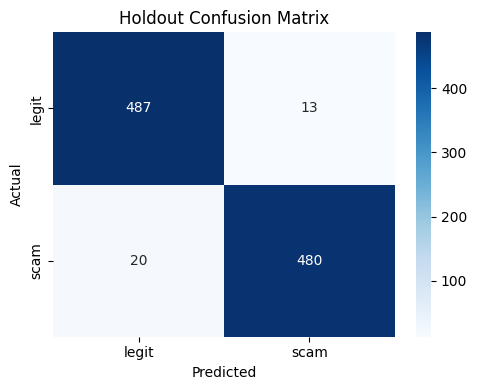

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['legit', 'scam'], yticklabels=['legit', 'scam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Holdout Confusion Matrix')
plt.tight_layout()
plt.show()


## Feature Importance


,importance
https,0.143458
uses_free_hosting,0.113321
url_entropy,0.101853
suspicious_tld,0.057999
token_count,0.041531
text_length,0.039193
avg_word_length,0.038590
num_hyphen,0.038140
num_digits,0.036719
path_depth,0.035888


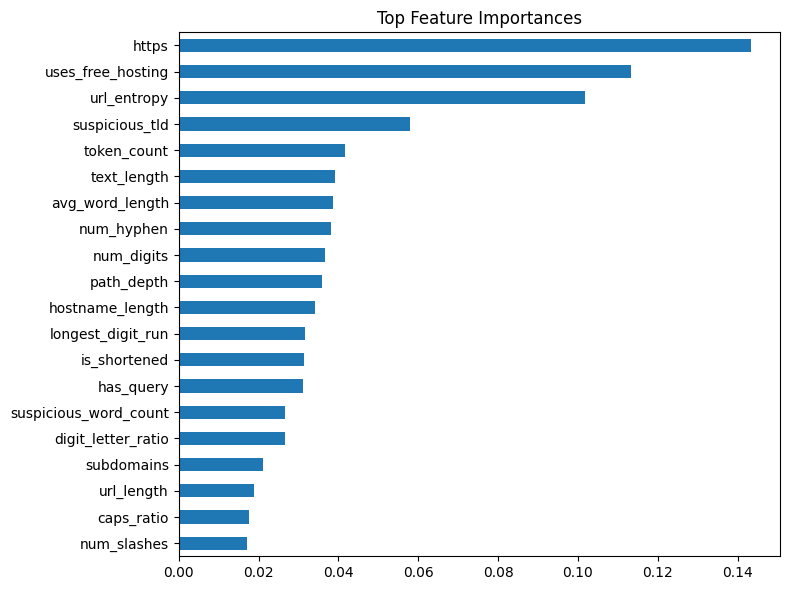

In [10]:
model_for_importance = best_model.named_steps['model']

if hasattr(model_for_importance, 'feature_importances_'):
    importance = pd.Series(model_for_importance.feature_importances_, index=feature_columns).sort_values(ascending=False)
    display(importance.head(20).to_frame('importance'))
    importance.head(20).sort_values().plot(kind='barh', figsize=(8, 6), title='Top Feature Importances')
    plt.tight_layout()
    plt.show()
elif hasattr(model_for_importance, 'coef_'):
    coefficients = pd.Series(model_for_importance.coef_[0], index=feature_columns).sort_values(key=np.abs, ascending=False)
    display(coefficients.head(20).to_frame('coefficient'))
else:
    print(f'Feature importance is not available for {best_model_name}.')


## Save Artifacts


In [11]:
model_path = MODEL_DIR / 'best_scam_detector.pkl'
features_path = MODEL_DIR / 'model_features.pkl'
report_path = MODEL_DIR / 'training_report.json'

joblib.dump(final_model, model_path)
joblib.dump(feature_columns, features_path)

report = {
    'dataset': str(DATA_PATH),
    'clean_dataset': str(CLEAN_DATA_PATH),
    'rows': int(len(clean)),
    'features': feature_columns,
    'best_model': best_model_name,
    'calibrated': bool(CALIBRATE),
    'cv_results': cv_results,
    'holdout_metrics': metrics,
}
report_path.write_text(json.dumps(report, indent=2), encoding='utf-8')

print(f'[OK] Saved model: {model_path}')
print(f'[OK] Saved features: {features_path}')
print(f'[OK] Saved report: {report_path}')


[OK] Saved model: pkl_models\best_scam_detector.pkl
[OK] Saved features: pkl_models\model_features.pkl
[OK] Saved report: pkl_models\training_report.json


## Prediction Helper


In [12]:
def predict_feature_row(feature_dict):
    loaded_model = joblib.load(MODEL_DIR / 'best_scam_detector.pkl')
    loaded_features = joblib.load(MODEL_DIR / 'model_features.pkl')
    frame = pd.DataFrame([feature_dict])
    for column in loaded_features:
        if column not in frame.columns:
            frame[column] = np.nan
    frame = frame[loaded_features]
    prediction = int(loaded_model.predict(frame)[0])
    probability = loaded_model.predict_proba(frame)[0] if hasattr(loaded_model, 'predict_proba') else None
    confidence = float(np.max(probability)) if probability is not None else 1.0
    return {
        'prediction': prediction,
        'label': 'SCAM' if prediction == 1 else 'LEGITIMATE',
        'confidence': confidence,
    }

sample_features = X.iloc[0].to_dict()
predict_feature_row(sample_features)


{'prediction': 0, 'label': 'LEGITIMATE', 'confidence': 0.9973544973544973}